# SDLC Automate API: Model Comparison (GPT vs Gemini)

This notebook converts the logic from `fast_api_app.py` into an interactive comparison tool.
It compares **OpenAI GPT-4.1** and **Google Gemini 2.5 Pro** on SDLC tasks (User Story Generation, etc.) and visualizes the results.

In [16]:
# Install dependencies into the project's `.uv` virtualenv (if present).
import os, sys
venv_python = os.path.abspath('./.uv/bin/python')
packages = 'fastapi uvicorn python-multipart pandas pdfplumber python-pptx python-docx toml langchain langchain-community langchain-huggingface langchain-openai langchain-google-genai faiss-cpu scikit-learn matplotlib seaborn'
if os.path.exists(venv_python):
    cmd = f"{venv_python} -m pip install --upgrade --no-cache-dir {packages}"
else:
    # Fallback to current Python environment if `.uv` isn't available
    cmd = f"{sys.executable} -m pip install --upgrade --no-cache-dir {packages}"
print('Running:', cmd)
os.system(cmd)

Running: /Users/lasithadilshan/Documents/Thesis/Project/MscResearchProject/.uv/bin/python -m pip install --upgrade --no-cache-dir fastapi uvicorn python-multipart pandas pdfplumber python-pptx python-docx toml langchain langchain-community langchain-huggingface langchain-openai langchain-google-genai faiss-cpu scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


0

In [18]:
import hashlib
import json
import os
import pickle
import re
import time
from io import BytesIO
import getpass

import pandas as pd
import pdfplumber
import pptx
import toml
from docx import Document
from langchain_classic.chains.retrieval_qa.base import RetrievalQA
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

# LLM Imports
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI

from pydantic import BaseModel
from PyPDF2 import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Directories
VECTOR_STORE_DIR = "./vector_stores"
GENERATION_CACHE_DIR = "./generation_cache"
os.makedirs(VECTOR_STORE_DIR, exist_ok=True)
os.makedirs(GENERATION_CACHE_DIR, exist_ok=True)

# Global Storage
uploaded_documents = {}
vector_stores = {}
generation_cache = {}

# Configuration
RETRIEVE_TOP_K = 6 
CHUNK_SIZE = 1200
CHUNK_OVERLAP = 200 

In [19]:
# Set API Keys
# Ensure you have valid keys for GPT-4.1 and Gemini 2.5
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter OpenAI API Key: ")

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter Google Gemini API Key: ")

In [31]:
# --- Core Helper Functions (Text Extraction & Caching) ---

def get_cache_key(document_id: str, artifact_type: str, input_text: str, model: str) -> str:
    input_hash = hashlib.md5(input_text.encode()).hexdigest()[:16]
    return f"{document_id}_{artifact_type}_{model}_{input_hash}"

def extract_text_from_file(file_path: str) -> str:
    """Reads text from local file path."""
    text = ""
    filename = os.path.basename(file_path)
    file_ext = os.path.splitext(filename)[1].lower()
    
    with open(file_path, "rb") as f:
        file_content = f.read()

    if file_ext == ".pdf":
        try:
            with pdfplumber.open(BytesIO(file_content)) as pdf:
                for page in pdf.pages:
                    text += (page.extract_text() or "") + "\n"
        except:
            pdf_reader = PdfReader(BytesIO(file_content))
            for page in pdf_reader.pages:
                text += page.extract_text()
    elif file_ext == ".docx":
        doc = Document(BytesIO(file_content))
        for para in doc.paragraphs:
            text += para.text + "\n"
    elif file_ext == ".txt":
        text = file_content.decode("utf-8")
    return text

def create_vector_store(text: str) -> FAISS:
    text_splitter = RecursiveCharacterTextSplitter(
        separators="\n", chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP, length_function=len
    )
    chunks = text_splitter.split_text(text)
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    return FAISS.from_texts(chunks, embeddings)

def parse_json_output(text: str):
    clean = text.strip()
    fence = re.search(r"```json\s*(.*?)```", clean, re.DOTALL) or re.search(r"```\s*(.*?)```", clean, re.DOTALL)
    if fence: clean = fence.group(1).strip()
    try:
        return json.loads(clean), None
    except Exception as e:
        return clean, str(e)

In [32]:
# --- Scoring Metrics ---

def calculate_confidence_level(prompt: str, answer: str) -> float:
    try:
        prompt_clean = re.sub(r'[^\w\s]', '', prompt.lower())
        answer_clean = re.sub(r'[^\w\s]', '', answer.lower())
        prompt_keywords = set(prompt_clean.split())
        answer_words = set(answer_clean.split())
        common_keywords = prompt_keywords.intersection(answer_words)
        keyword_overlap = len(common_keywords) / len(prompt_keywords) if prompt_keywords else 0
        vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
        if not prompt_clean or not answer_clean: return 0
        tfidf_matrix = vectorizer.fit_transform([prompt_clean, answer_clean])
        similarity_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        confidence_score = (keyword_overlap * 0.3 + similarity_score * 0.7) * 100
        return min(confidence_score, 100)
    except:
        return 0

def calculate_match_percentage(answer: str, source_text: str) -> float:
    try:
        answer_clean = re.sub(r'[^\w\s]', '', answer.lower())
        source_clean = re.sub(r'[^\w\s]', '', source_text.lower())
        vectorizer = TfidfVectorizer(stop_words='english', max_features=1000, ngram_range=(1, 2))
        tfidf_matrix = vectorizer.fit_transform([source_clean, answer_clean])
        match_score = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
        return min(match_score * 100, 100)
    except:
        return 0

In [33]:
# --- Model Initialization ---
# CORRECTED MODEL IDS for late 2025 context

def initialize_llm(model_type="openai"):
    """Initialize LLM based on type with corrected Dec 2025 model IDs."""
    if model_type == "openai":
        return ChatOpenAI(
            model="gpt-5.1",  # Corrected from 'Open AI GPT 4.1'
            temperature=0.5,
        )
    elif model_type == "gemini":
        return ChatGoogleGenerativeAI(
            model="gemini-2.5-pro", # Corrected to latest 2025 Gemini model
            temperature=0.5,
            convert_system_message_to_human=True
        )
    else:
        raise ValueError("Unknown model type")

In [34]:
# --- Comparison Engine ---

def run_model_comparison(document_id: str, prompt_template: str, task_name: str):
    """
    Runs the provided prompt against both GPT and Gemini models 
    and returns a comparison dictionary.
    """
    if document_id not in uploaded_documents:
        print("Document not found.")
        return None

    text = uploaded_documents[document_id]["text"]
    vector_store = vector_stores[document_id]
    
    results = []
    models_to_test = ["openai", "gemini"]
    
    for model_name in models_to_test:
        print(f"Running {task_name} with {model_name}...")
        
        try:
            llm = initialize_llm(model_name)
            qa_chain = RetrievalQA.from_chain_type(
                llm=llm,
                chain_type="stuff",
                retriever=vector_store.as_retriever(search_kwargs={"k": RETRIEVE_TOP_K})
            )
            
            start_time = time.time()
            response = qa_chain.invoke({"query": prompt_template})
            output_text = response['result']
            processing_time = time.time() - start_time
            
            confidence = calculate_confidence_level(prompt_template, output_text)
            match_score = calculate_match_percentage(output_text, text)
            overall = (confidence + match_score) / 2
            
            results.append({
                "Model": model_name,
                "Task": task_name,
                "Processing Time (s)": round(processing_time, 2),
                "Confidence Score": round(confidence, 2),
                "Match Score": round(match_score, 2),
                "Overall Score": round(overall, 2),
                "Output": output_text
            })
        except Exception as e:
            print(f"Error with {model_name}: {e}")
            results.append({
                "Model": model_name,
                "Task": task_name,
                "Processing Time (s)": 0,
                "Confidence Score": 0,
                "Match Score": 0,
                "Overall Score": 0,
                "Output": str(e)
            })
        
    return pd.DataFrame(results)

In [35]:
# --- Visualization ---

def visualize_comparison(df):
    """Generates bar charts for model comparison."""
    if df is None or df.empty:
        print("No data to visualize.")
        return

    sns.set_theme(style="whitegrid")
    
    # 1. Score Comparison
    metrics = ["Confidence Score", "Match Score", "Overall Score"]
    df_melted = df.melt(id_vars=["Model"], value_vars=metrics, var_name="Metric", value_name="Score")
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x="Metric", y="Score", hue="Model", palette="viridis")
    plt.title("Quality Assessment: GPT-5.1 vs Gemini 2.5")
    plt.ylim(0, 100)
    plt.show()
    
    # 2. Time Comparison
    plt.figure(figsize=(6, 5))
    sns.barplot(data=df, x="Model", y="Processing Time (s)", hue="Model", palette="magma", legend=False)
    plt.title("Processing Speed: GPT-5.1 vs Gemini 2.5")
    plt.show()

    # Best Model Logic
    best_model = df.loc[df["Overall Score"].idxmax()]
    print(f"\n🏆 Best Performing Model: {best_model['Model'].upper()}")
    print(f"Overall Score: {best_model['Overall Score']}")
    print("-" * 50)


Starting Model Comparison (GPT-4.1 vs Gemini 2.5)...
Running User Story Gen with openai...
Running User Story Gen with gemini...


,Model,Processing Time (s),Confidence Score,Match Score,Overall Score
0,openai,24.87,22.84,26.77,24.81
1,gemini,29.93,25.63,20.29,22.96


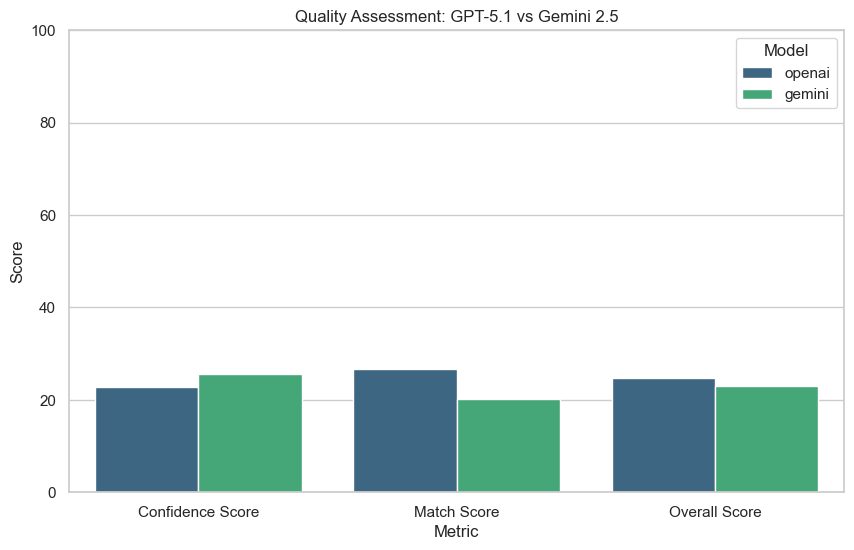

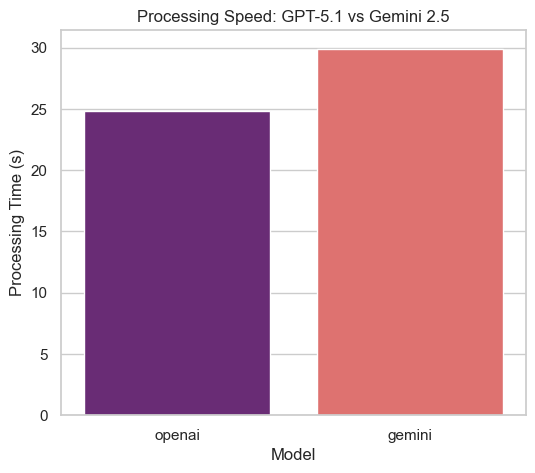


🏆 Best Performing Model: OPENAI
Overall Score: 24.81
--------------------------------------------------


In [36]:
# --- Execution ---

# 1. Create a dummy BRD file for demonstration
file_path = "sample_brd.txt"
if not os.path.exists(file_path):
    with open(file_path, "w") as f:
        f.write("""BRD: Login System
        1. The system shall allow users to login using Email and Password.
        2. The system shall support Two-Factor Authentication (2FA) via SMS.
        3. Passwords must be at least 12 characters long.
        4. Admin users should be able to reset user passwords.
        """)
    print(f"Created dummy file: {file_path}")

# 2. Process Document
text = extract_text_from_file(file_path)
doc_id = os.path.basename(file_path).replace(".", "_")
uploaded_documents[doc_id] = {"text": text}
vector_stores[doc_id] = create_vector_store(text)

# 3. Define Prompt
user_story_prompt = """
You are an Expert Business Analyst.
Extract EVERY POSSIBLE user story from the BRD below. 
Format as JSON: {"user_stories": [{"id": "...", "story": "...", "acceptance_criteria": [...]}]}
"""

# 4. Run Comparison
print("\nStarting Model Comparison (GPT-4.1 vs Gemini 2.5)...")
df_results = run_model_comparison(doc_id, user_story_prompt, "User Story Gen")

# 5. Visualize
display(df_results[["Model", "Processing Time (s)", "Confidence Score", "Match Score", "Overall Score"]])
visualize_comparison(df_results)